In [9]:
import requests
import pandas as pd
from datetime import datetime

# Tọa độ trung tâm TP.HCM
lat = 10.7756
lon = 106.7019

# Thiết lập thời gian: Từ 01/01/2026 đến ngày hôm nay
start_date = "2026-01-01"
end_date = datetime.today().strftime('%Y-%m-%d')

print(f"Đang tiến hành cào dữ liệu AQI từ {start_date} đến {end_date}...")

# Endpoint API Historical của Open-Meteo
url = (
    f"https://air-quality-api.open-meteo.com/v1/air-quality?"
    f"latitude={lat}&longitude={lon}&"
    f"start_date={start_date}&end_date={end_date}&"
    f"hourly=pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,european_aqi&"
    f"timezone=Asia/Bangkok"
)

# Gửi yêu cầu lấy dữ liệu
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    
    # Bóc tách phần dữ liệu theo giờ (hourly)
    hourly_data = data['hourly']
    
    # Đóng gói vào Pandas DataFrame cho dễ nhìn
    df = pd.DataFrame({
        'Time': hourly_data['time'],
        'AQI': hourly_data['european_aqi'],
        'PM2.5': hourly_data['pm2_5'],
        'PM10': hourly_data['pm10'],
        'CO': hourly_data['carbon_monoxide'],
        'NO2': hourly_data['nitrogen_dioxide'],
        'SO2': hourly_data['sulphur_dioxide'],
        'O3': hourly_data['ozone']
    })
    
    # Xóa các dòng bị thiếu dữ liệu (nếu có)
    df = df.dropna()

    # Lưu thành file CSV để bạn múa biểu đồ hoặc nhét vào model AI
    filename = "hcm_aqi_historical_2026.csv"
    df.to_csv(filename, index=False)
    
    print(f"\n✅ THÀNH CÔNG! Đã cào được {len(df)} giờ quan trắc.")
    print(f"Đã lưu vào file: {filename}")
    
    # In thử 5 dòng đầu tiên xem mặt mũi data ra sao
    print("\nTrích xuất 5 dòng đầu tiên:")
    print(df.head())
else:
    print(f"❌ Lỗi rồi! Mã lỗi: {response.status_code}")
    print(response.text)

Đang tiến hành cào dữ liệu AQI từ 2026-01-01 đến 2026-03-15...

✅ THÀNH CÔNG! Đã cào được 1776 giờ quan trắc.
Đã lưu vào file: hcm_aqi_historical_2026.csv

Trích xuất 5 dòng đầu tiên:
               Time  AQI  PM2.5  PM10     CO   NO2  SO2    O3
0  2026-01-01T00:00   52   12.4  14.1  369.0  22.1  7.8  74.0
1  2026-01-01T01:00   52   12.0  13.7  330.0  22.3  7.4  72.0
2  2026-01-01T02:00   51   12.2  13.9  305.0  22.4  7.1  68.0
3  2026-01-01T03:00   51   13.0  14.8  301.0  22.9  7.2  64.0
4  2026-01-01T04:00   51   14.2  16.1  362.0  24.5  7.9  59.0


In [10]:
df.tail(5)

,Time,AQI,PM2.5,PM10,CO,NO2,SO2,O3
1771,2026-03-15T19:00,61,13.8,14.8,636.0,24.0,7.6,84.0
1772,2026-03-15T20:00,61,12.8,13.9,618.0,24.8,8.1,75.0
1773,2026-03-15T21:00,60,13.6,14.6,574.0,23.9,8.1,70.0
1774,2026-03-15T22:00,60,15.2,16.2,526.0,23.3,7.9,65.0
1775,2026-03-15T23:00,59,15.7,16.5,474.0,23.7,7.3,60.0


C:\Users\nguye\AppData\Local\Temp\ipykernel_51080\940137275.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_thang_2['Ngay'] = df_thang_2['Time'].dt.day


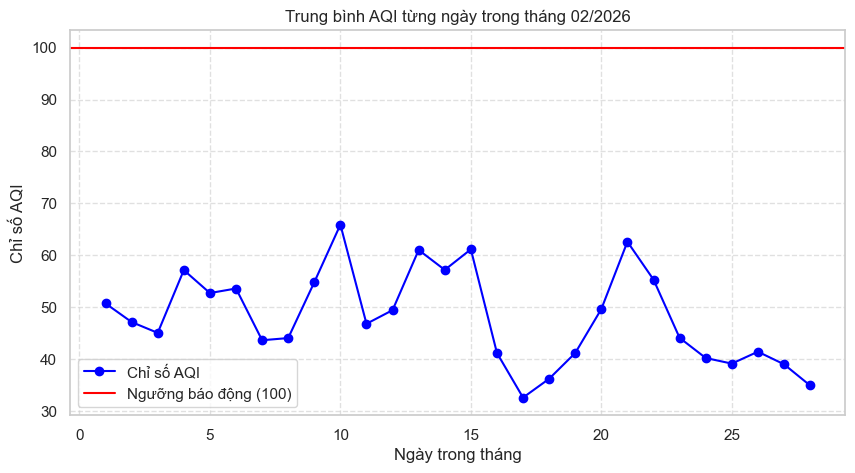

In [12]:
import matplotlib.pyplot as plt

# 1. Lọc data: Lấy tất cả dữ liệu thuộc Tháng 2 năm 2026
df['Time'] = pd.to_datetime(df['Time'])  # Đảm bảo cột 'Time' là kiểu datetime
df_thang_2 = df[(df['Time'].dt.month == 2) & (df['Time'].dt.year == 2026)]

# Tính trung bình AQI mỗi ngày (để 1 ngày chỉ có 1 điểm trên biểu đồ cho đỡ rối)
# Tạo cột 'Ngay' (từ 1 đến 28)
df_thang_2['Ngay'] = df_thang_2['Time'].dt.day
daily_aqi_feb = df_thang_2.groupby('Ngay')['AQI'].mean().reset_index()

# 2. Khởi tạo biểu đồ cho rộng rãi một xíu để chứa 28 ngày
plt.figure(figsize=(10, 5))

# 3. Vẽ đường AQI (trục X là 'Ngay', trục Y là 'AQI')
plt.plot(daily_aqi_feb['Ngay'], daily_aqi_feb['AQI'], marker='o', color='blue', label='Chỉ số AQI')

# 4. Kẻ đường ngang cảnh báo ở mức 100
plt.axhline(y=100, color='red', linestyle='-', label='Ngưỡng báo động (100)')

# 5. Thêm lưới mờ mờ cho dễ nhìn số
plt.grid(True, linestyle='--', alpha=0.6)

# 6. Viết chú thích
plt.title('Trung bình AQI từng ngày trong tháng 02/2026')
plt.xlabel('Ngày trong tháng')
plt.ylabel('Chỉ số AQI')
plt.legend()

# 7. Hiện hình!
plt.show()